# make maps
first read data

gambelii      stellata muehlenbergii    macrocarpa          alba 
           21            21            21            22            21 
       lyrata     michauxii       bicolor       montana       sinuata 
           21            21            21            21            21

Reading layer `macrocarpa_little' from data source 
  `/home/andrew/Dropbox/NSF-DOB-BurOak-core-files/PAPERS-AND-PROJECTS/KHUFU/2024/v3/data/little-maps/shapefiles/macrocarpa_little.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 44 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -1768918 ymin: -1179409 xmax: 1241940 ymax: 1541501
Projected CRS: +proj=aea ++lon_0=-82 +ellps=clrk66 +lat_1=38 +lat_2=42 +lat_0=40 +units=m +x_0=0 +y_0=0 +datum=WGS84 +axis=enu


Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”


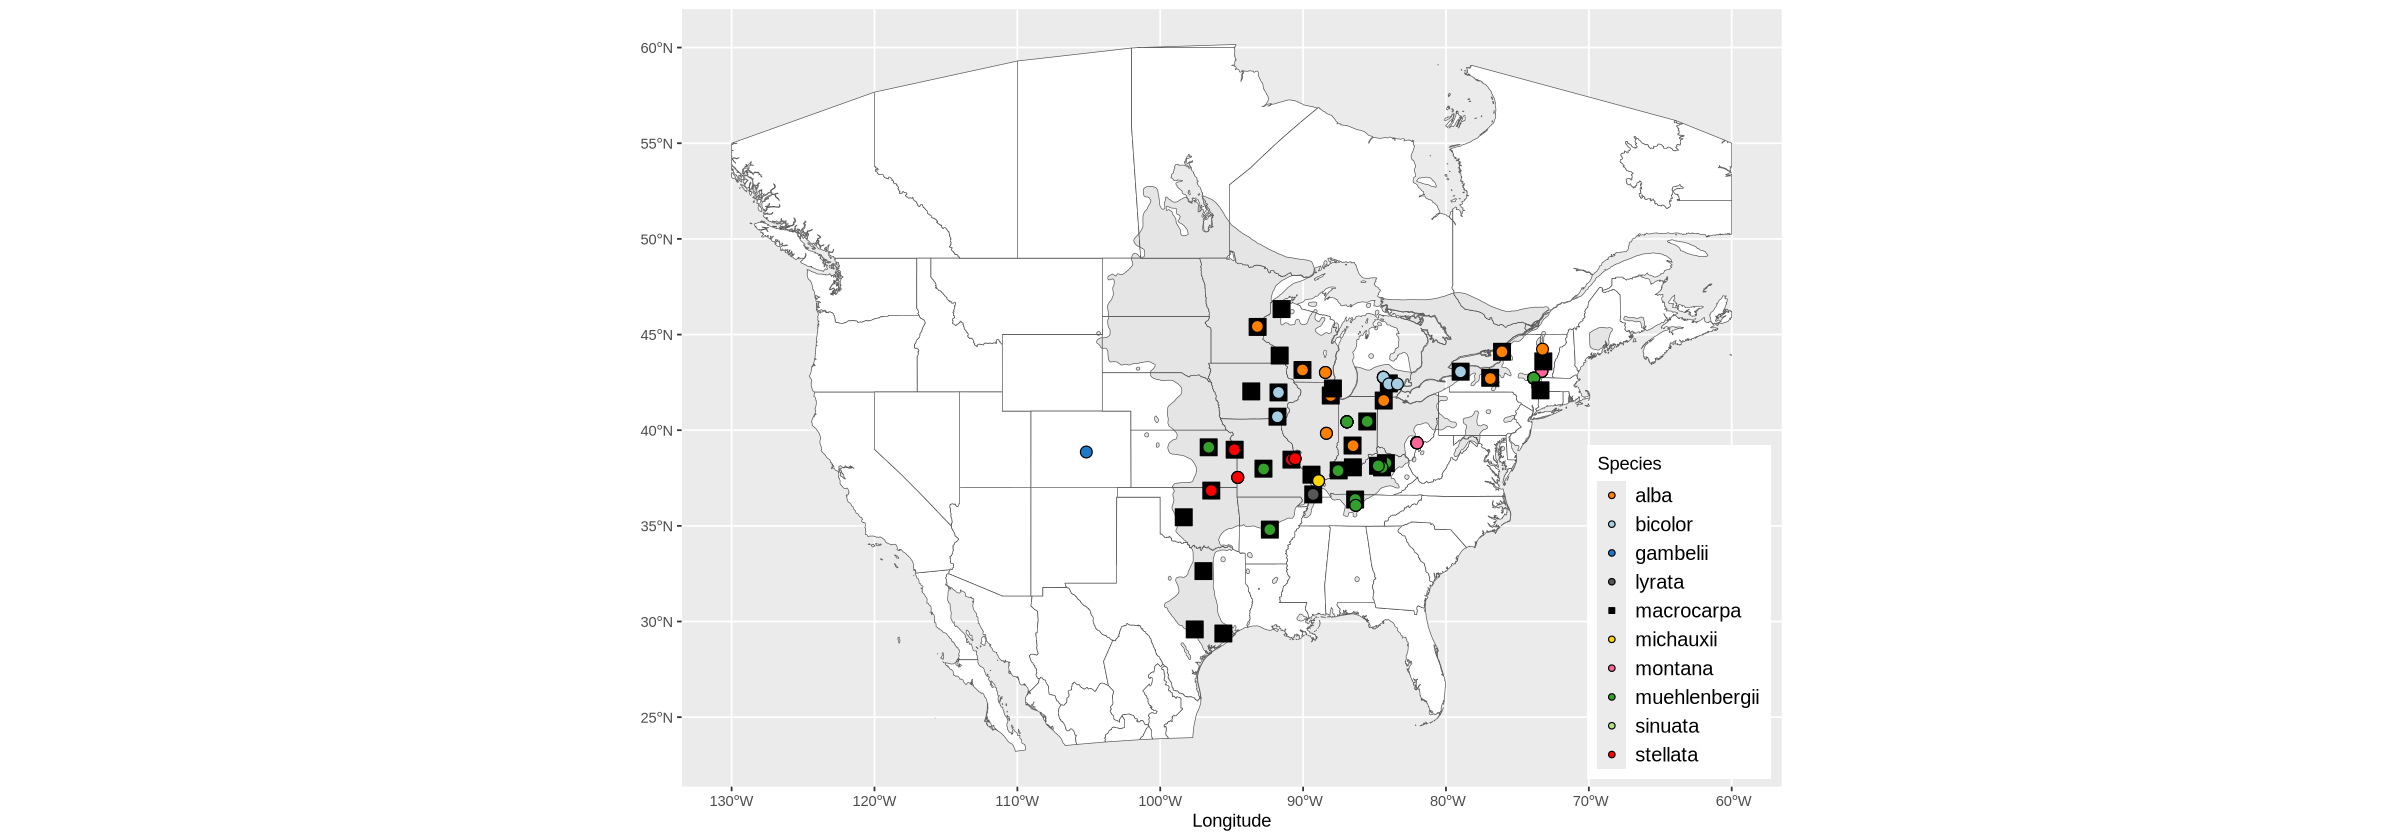

In [5]:
# v2, 2024-11-05 -- adds little outlines

options(repr.plot.width = 20)
library(pals)
library(ggplot2)
library(tidyverse)
library(rgdal)
library(proj4)
library(sf)
library(dplyr)
library(rnaturalearth)
library(ggbeeswarm)
# library(rnaturalearthhires)

# library(ggmap)
# library(maps)
# library(mapdata)
# library(ggrepel)



dat.maps <- read.csv('../data/acorn_collections.csv')
metadata.all <- read.csv('../out/oak.metadata.cleaned.csv')
metadata.all$Longitude <- ifelse(is.na(metadata.all$longitude.orig), metadata.all$longitude_georef, metadata.all$longitude.orig)
metadata.all$Latitude <- ifelse(is.na(metadata.all$latitude.orig), metadata.all$latitude_georef, metadata.all$latitude.orig)
metadata.rangewide <- metadata.all[grep('_', metadata.all$Qsp, fixed = T, invert = T), ]
names(metadata.rangewide)[names(metadata.rangewide) == 'Qsp'] <- 'Species'
spp <- unique(metadata.rangewide$Species)
if(length(spp) > 9) colSet <- structure(cols25()[1:length(spp)], names = spp)
if(length(spp)  <= 9) colSet <- structure(palette.colors(length(spp), palette = "Okabe-Ito"), names = spp)
colSet['macrocarpa'] <- 'black'
sizeSet <- structure(ifelse(spp == 'macrocarpa', 5, 3), names = spp)
shapeSet <- structure(ifelse(spp == 'macrocarpa', 22, 21), names = spp)
# shapeSet
mothers.all <- read.csv('../out/vcf.stats.raw.table.csv')
mothers.imputed <- read.csv('../out/vcf.stats.imputed.table.csv')

###### BEGIN LITTLE SHAPEFILE SECTION, from 2019 paper

proj <- "+proj=aea ++lon_0=-82 +ellps=clrk66 +lat_1=38 +lat_2=42 +lat_0=40 +units=m +x_0=0 +y_0=0 +datum=WGS84 +axis=enu"

# Source data

# spp.little <- c('macrocarpa', 'alba', 'muehlenbergii', 'bicolor')
spp.little <- c('macrocarpa')

# borrowed from Ribicoff, https://github.com/gribicoff/qmac_hybseq/blob/main/map_sppranges_sites.R
if(!exists('mapsLittle')) {
    ## 
    rlist <- sapply(spp.little, function(x) {
      st_read(paste0("../data/little-maps/shapefiles/", x, "_little.shp"), crs = proj) %>%
      st_cast("MULTIPOLYGON")
    }, simplify = FALSE)
    
    rlist[["bicolor"]] <- rlist[["bicolor"]][-12,] # removes Lake Winnebago
    rlist[["macrocarpa"]] <- rlist[["macrocarpa"]][-c(2,3,18),] # removes Lake Winnipeg, Lake of the Woods, Lake Winnebago respectively
    rlist[["alba"]] <- rlist[["alba"]][-c(7,13,19,20),] # removes the Adirondacks, Lake Winnebago, Lake Erie/Saint Clair, the Catskills respectively
  }

namap <- ne_states(c("United States of America", "Canada", "Mexico"), returnclass = "sf")
namap <- namap %>%
  st_crop(c(xmin = -130, xmax = -60, ymin = 20, ymax = 55))

p <- ggplot()
p <- p + geom_sf(data = namap, fill = 'white')

a <- c(macrocarpa = 0.1, alba = 0.2, muehlenbergii = 0.2, bicolor = 0.6)
ld <- c(macrocarpa = 1, alba = 0.5, muehlenbergii = 0.5, bicolor = 1)
ld['macrocarpa'] <- 0

for(i in spp.little) {
    p <- p + geom_sf(data = rlist[[i]], alpha = a[i], fill = colSet[i])
    p <- p + geom_sf(data = rlist[[i]], fill = NA, color = colSet[i], lwd = ld[i])
    }
p <- p + scale_x_continuous('')
p <- p + scale_y_continuous('')

p.all <- p + geom_point(data = metadata.rangewide, 
                            mapping = aes(Longitude, Latitude, fill = Species, shape = Species, group = NA),
                            color = 'black', size = sizeSet[metadata.rangewide$Species])


p.all <- p.all + scale_fill_manual(values = colSet) + scale_shape_manual(values = shapeSet)
p.all <- p.all + theme(
    legend.position = c(.99, .01),
    legend.justification.inside = c("right", "bottom"),
    legend.box.just = "right",
    legend.margin = margin(6, 6, 6, 6),
    legend.text = element_text(size = 12)
    )
p.all <- p.all + xlim(-130, -60)

print(p.all)
ggsave('../out/FIGx.rangewideSamples.pdf', width = 11, height = 8.5, units = 'in')

In [11]:
table(metadata.rangewide$Species)


         alba       bicolor      gambelii        lyrata    macrocarpa 
           57            25             2            15            37 
    michauxii       montana muehlenbergii       sinuata      stellata 
           12             7            50             4            27 

In [8]:
tail(dat.maps)

,Date.collected,Latitude,Longitude,State,Mother.ID,Site.ID,Unique.Code,Site
,<chr>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
122,10/30/2019,35.42194,-97.51222,OK,24,DRA4,OK-DRA-24,Draper Park
123,10/30/2019,35.42278,-97.51194,OK,25,DRA5,OK-DRA-25,Draper Park
124,10/30/2019,35.42278,-97.51139,OK,26,DRA6,OK-DRA-26,Draper Park
125,10/30/2019,35.42333,-97.51167,OK,27,DRA7,OK-DRA-27,Draper Park
126,10/31/2019,34.98056,-97.52167,OK,28,KES1,OK-KES-28,Kessler Atmospheric and Ecological Field Station
127,10/31/2019,35.18722,-97.42861,OK,29,JIM1,OK-JIM-29,Jimmy Austin Golf Course


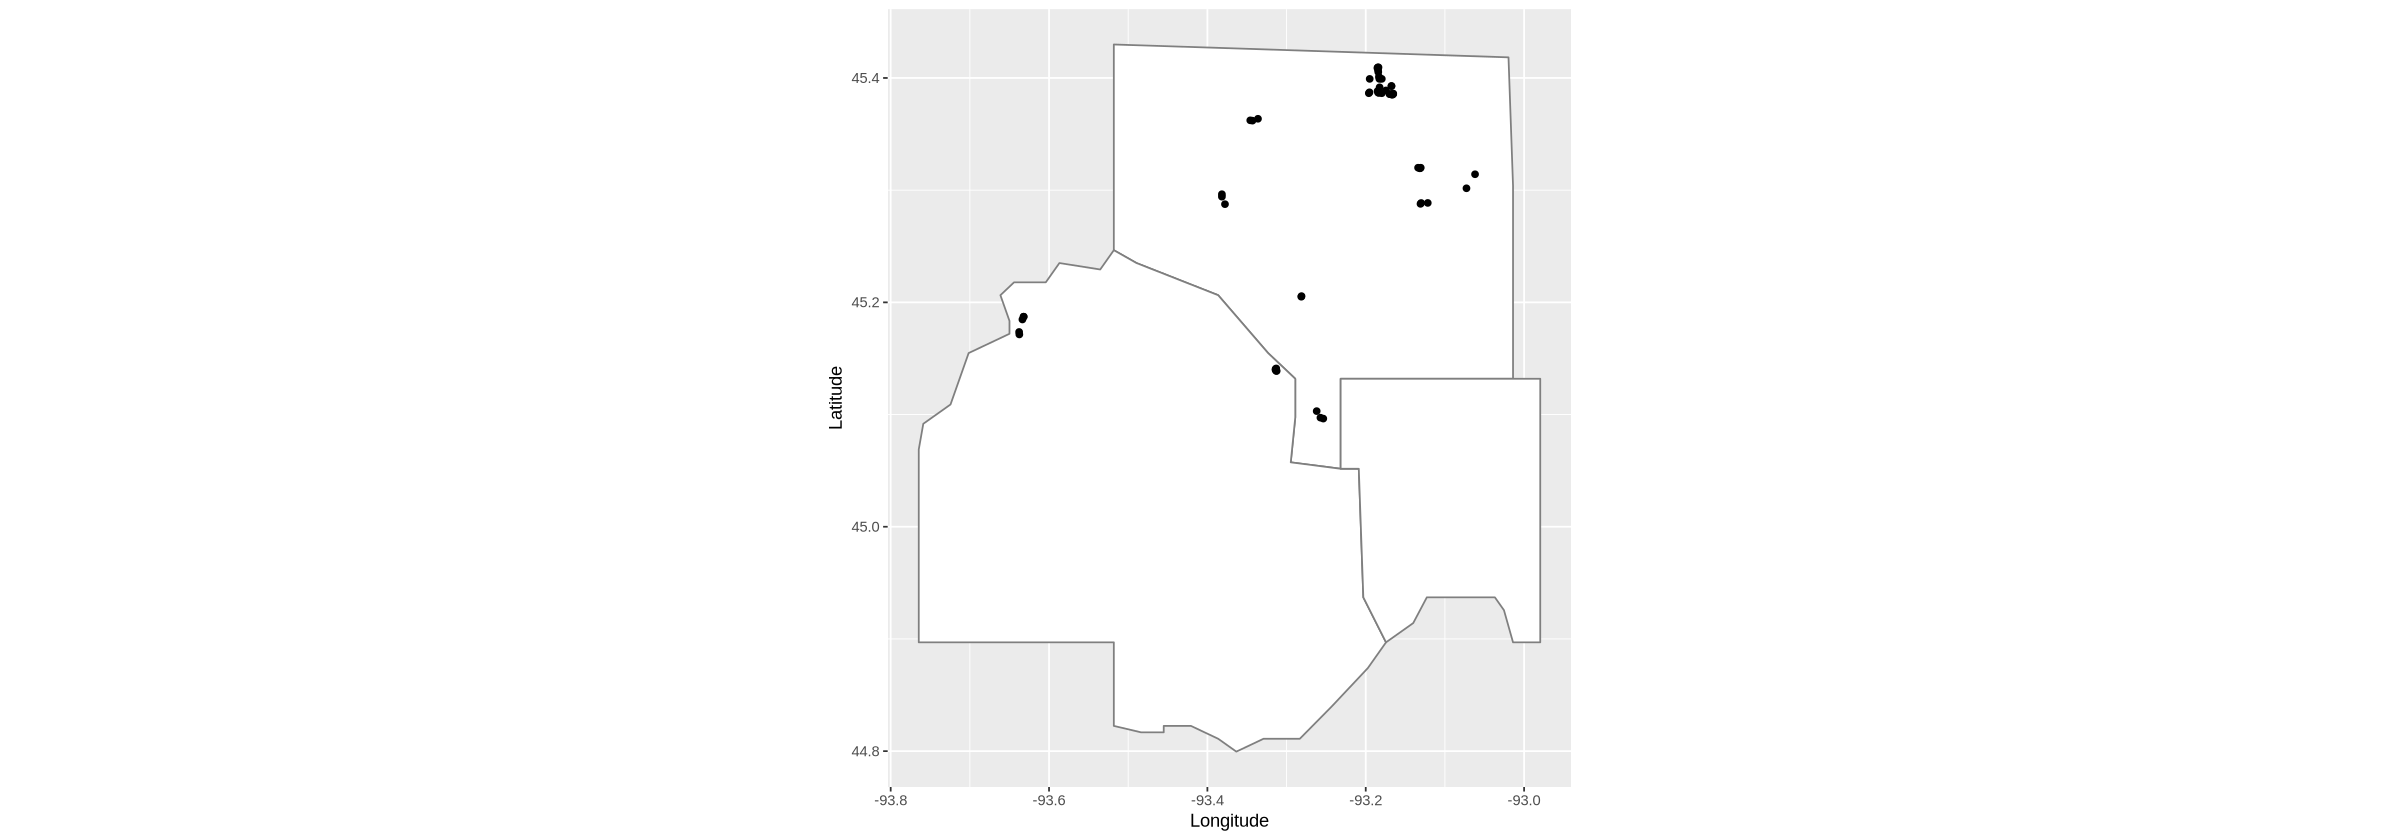

In [2]:
# options(repr.plot.height = 15)
basemap <- map_data("county", "minnesota") %>% 
  select(lon = long, lat, group, id = subregion)
basemap <- basemap[basemap$id %in% c('ramsey', 'anoka', 'hennepin'), ]
names(basemap)[1:2] <- c('Longitude', 'Latitude')
p = ggplot(basemap, aes(Longitude, Latitude, group = group)) +
  geom_polygon(fill = "white", colour = "grey50") + 
  coord_quickmap() 

p = p + geom_point(data = dat.maps[which(dat.maps$State == 'MN'), ], mapping = aes(Longitude, Latitude, group = NULL))
p